In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df= pd.read_csv("basotho_wool.csv")
df.head()

,ref_period_id,ref_year,ref_month,period,reporter_code,reporter_iso,reporter_desc,flow_code,classification_code,cmd_code,...,is_qty_estimated,alt_qty_unit_code,alt_qty_unit_abbr,alt_qty,net_wgt,is_net_wgt_estimated,cifvalue,fobvalue,primary_value,legacy_estimation_flag
0,20100101,2010,1,201001,710,ZAF,South Africa,M,H3,5101,...,False,8,kg,360890.0,360890.0,False,NaN,486974.381,486974.381,0
1,20100201,2010,2,201002,710,ZAF,South Africa,M,H3,5101,...,False,8,kg,2048.0,2048.0,False,NaN,347266.594,347266.594,0
2,20100301,2010,3,201003,710,ZAF,South Africa,M,H3,5101,...,False,8,kg,27869.0,27869.0,False,NaN,65188.944,65188.944,0
3,20100401,2010,4,201004,710,ZAF,South Africa,M,H3,5101,...,False,8,kg,27.0,27.0,False,NaN,12909.728,12909.728,0
4,20100501,2010,5,201005,710,ZAF,South Africa,M,H3,5101,...,False,8,kg,2.0,2.0,False,NaN,2875.444,2875.444,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ref_period_id           293 non-null    int64  
 1   ref_year                293 non-null    int64  
 2   ref_month               293 non-null    int64  
 3   period                  293 non-null    int64  
 4   reporter_code           293 non-null    int64  
 5   reporter_iso            293 non-null    str    
 6   reporter_desc           293 non-null    str    
 7   flow_code               293 non-null    str    
 8   classification_code     293 non-null    str    
 9   cmd_code                293 non-null    int64  
 10  cmd_desc                293 non-null    str    
 11  qty_unit_code           293 non-null    int64  
 12  qty_unit_abbr           266 non-null    str    
 13  qty                     292 non-null    float64
 14  is_qty_estimated        293 non-null    bool   
 15  

In [5]:
df.columns.to_list()

['ref_period_id',
 'ref_year',
 'ref_month',
 'period',
 'reporter_code',
 'reporter_iso',
 'reporter_desc',
 'flow_code',
 'classification_code',
 'cmd_code',
 'cmd_desc',
 'qty_unit_code',
 'qty_unit_abbr',
 'qty',
 'is_qty_estimated',
 'alt_qty_unit_code',
 'alt_qty_unit_abbr',
 'alt_qty',
 'net_wgt',
 'is_net_wgt_estimated',
 'cifvalue',
 'fobvalue',
 'primary_value',
 'legacy_estimation_flag']

In [6]:
df.isna().sum()

ref_period_id              0
ref_year                   0
ref_month                  0
period                     0
reporter_code              0
reporter_iso               0
reporter_desc              0
flow_code                  0
classification_code        0
cmd_code                   0
cmd_desc                   0
qty_unit_code              0
qty_unit_abbr             27
qty                        1
is_qty_estimated           0
alt_qty_unit_code          0
alt_qty_unit_abbr         47
alt_qty                    1
net_wgt                    0
is_net_wgt_estimated       0
cifvalue                  69
fobvalue                  53
primary_value              0
legacy_estimation_flag     0
dtype: int64

In [20]:
df_clean= df.copy() #Making a indepedent copy of the df before cleaning

#Drop rows where both cifvalue and fobvalue are missing
df_clean= df_clean.dropna(subset=["cifvalue","fobvalue"], how="all") #subset indicates only drop a row if these specific columns are missing otherwise without it ,drops any row that has a missing value in any column

#Fill the missing cifvalue with fobvalue where cifvalue is NaN
df_clean["cifvalue"]= df_clean["cifvalue"].fillna(df_clean["fobvalue"])
df_clean["fobvalue"]= df_clean["fobvalue"].fillna(df_clean["cifvalue"])


#Fill missing abbreviations
df_clean["qty_unit_abbr"]=df_clean["qty_unit_abbr"].fillna("unknown")
df_clean["alt_qty_unit_abbr"]=df_clean["alt_qty_unit_abbr"].fillna("unknown")

#Fill missing quantities with median
df_clean["qty"]=df_clean["qty"].fillna(df_clean["qty"].median())
df_clean["alt_qty"]=df_clean["alt_qty"].fillna(df_clean["alt_qty"].median())

df_clean.isna().sum()


ref_period_id             0
ref_year                  0
ref_month                 0
period                    0
reporter_code             0
reporter_iso              0
reporter_desc             0
flow_code                 0
classification_code       0
cmd_code                  0
cmd_desc                  0
qty_unit_code             0
qty_unit_abbr             0
qty                       0
is_qty_estimated          0
alt_qty_unit_code         0
alt_qty_unit_abbr         0
alt_qty                   0
net_wgt                   0
is_net_wgt_estimated      0
cifvalue                  0
fobvalue                  0
primary_value             0
legacy_estimation_flag    0
dtype: int64

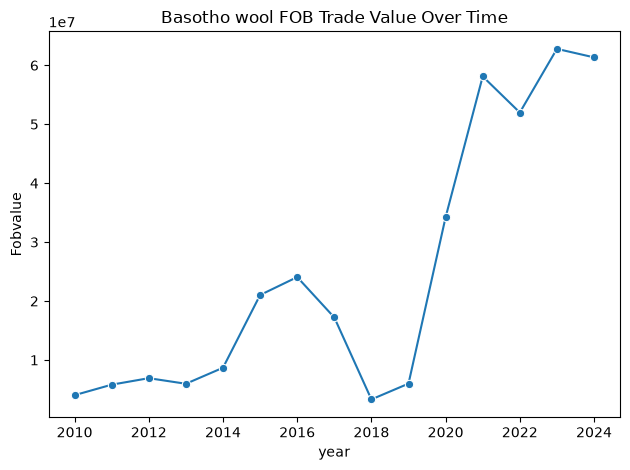

In [15]:
#Line Chart showing Basotho Wool FOB Trade Over Time
df_clean["ref_year"] = df_clean["ref_year"].astype(int) #Converts to integer form
yearly=df_clean.groupby("ref_year")["fobvalue"].sum().reset_index() ##Groups all rows by year and adds up all the fobvalues numbers for each year into one total

plt.Figure(figsize=(12,6))
sns.lineplot(data=yearly,x="ref_year",y="fobvalue",markers="True",marker="o")
plt.title("Basotho wool FOB Trade Value Over Time")
plt.xlabel("year")
plt.ylabel("Fobvalue")
plt.tight_layout()
plt.show()

#Insights
#1).Massive Growth overall, FOB value went from around 0.3x10*7 in 2010 to over 6x10*7 by 2022/2023.That's roughy a 30x increase over 14 years.
#2).There was a sharp crash in 2017 - 2018

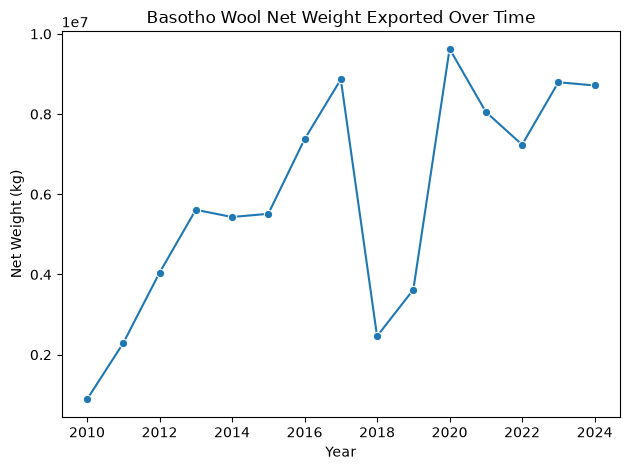

In [21]:
#Line Chart showing Basotho Wool Net Weight Exported Over Time
yearly_wgt = df_clean.groupby("ref_year")["net_wgt"].sum().reset_index()
plt.Figure(figsize=(10,6))
sns.lineplot(data=yearly_wgt, x="ref_year", y="net_wgt",markers="True",marker="o")
plt.title("Basotho Wool Net Weight Exported Over Time")
plt.xlabel("Year")
plt.ylabel("Net Weight (kg)")
plt.tight_layout()
plt.show()

#Insights
#1).Weight peaked around 2016 and again 2020 then fluctuated while value kept climbing to 2020,meaning after 2020 prices per kg went up even as volume stabilized
#2).Weight in 2024 is holding steady while value slightly dipped. It suggests prices softened but volume remained.

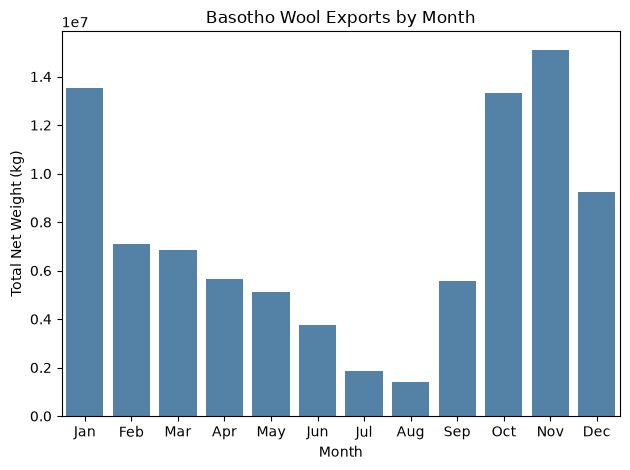

In [23]:
# Bar chart showing Basotho Wool Exports by Month
monthly = df_clean.groupby("ref_month")["net_wgt"].sum().reset_index()
plt.Figure(figsize=(10,6))
sns.barplot(data=monthly, x="ref_month", y="net_wgt",color="steelblue")
plt.title("Basotho Wool Exports by Month")
plt.xlabel("Month")
plt.ylabel("Total Net Weight (kg)")
plt.xticks(ticks=range(12), labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

#Insights
#1).Peak months are January and November.
#2).Mid year is the dead season. July and August are the lowest months by far, almost flat.
#3).April to June there is dcline. After January peak exports drop steadly through the first half of the year.